In [ ]:
import pandas as pd

movies = pd.read_csv("/movies.csv")
ratings = pd.read_csv("/ratings.csv")

movies.head()
ratings.head()

,userId,movieId,rating,timestamp
0,1,17.0,4.0,944249077.0
1,1,25.0,1.0,944250228.0
2,1,29.0,2.0,943230976.0
3,1,30.0,5.0,944249077.0
4,1,32.0,5.0,943228858.0


In [ ]:
df = pd.merge(ratings, movies, on='movieId')
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,17.0,4.0,944249077.0,Sense and Sensibility (1995),Drama|Romance
1,1,25.0,1.0,944250228.0,Leaving Las Vegas (1995),Drama|Romance
2,1,29.0,2.0,943230976.0,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi
3,1,30.0,5.0,944249077.0,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama
4,1,32.0,5.0,943228858.0,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller


In [ ]:
df.dropna(inplace=True)

In [ ]:
df['title'].value_counts().head(10)

,count
title,
"Shawshank Redemption, The (1994)",81148
Forrest Gump (1994),79026
Pulp Fiction (1994),77498
"Matrix, The (1999)",73814
"Silence of the Lambs, The (1991)",71125
Star Wars: Episode IV - A New Hope (1977),66875
Fight Club (1999),60893
Jurassic Park (1993),59204
Schindler's List (1993),58182


In [ ]:
avg_rating = df.groupby('title')['rating'].mean().sort_values(ascending=False)
avg_rating.head(10)

,rating
title,
$uperthief: Inside America's Biggest Bank Score (2012),5.0
줄탁동시 (2012),5.0
The Royal Hunt of the Sun (1969),5.0
Beverly Hills Wedding (2021),5.0
The Rogue Stallion (1990),5.0
The Road to Terror (1989),5.0
Joy For Christmas (2021),5.0
Last Flight (2014),5.0
Waltz Across Texas (1982),5.0


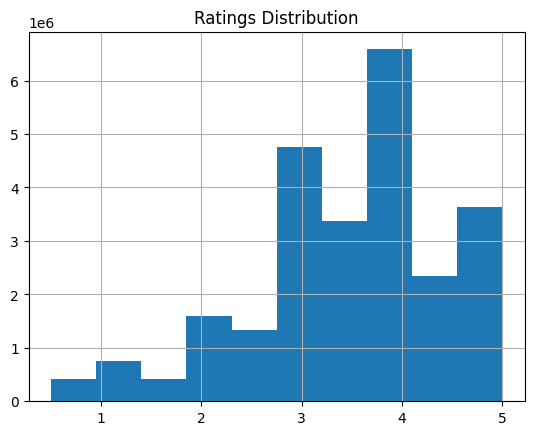

In [ ]:
import matplotlib.pyplot as plt

df['rating'].hist()
plt.title("Ratings Distribution")
plt.show()

In [ ]:
movies['genres'] = movies['genres'].apply(lambda x: x.split('|'))

from collections import Counter
all_genres = [g for sub in movies['genres'] for g in sub]

Counter(all_genres)

Counter({'Adventure': 5402,
         'Animation': 4617,
         'Children': 4520,
         'Comedy': 23124,
         'Fantasy': 3851,
         'Romance': 10369,
         'Drama': 34175,
         'Action': 9668,
         'Crime': 6976,
         'Thriller': 11823,
         'Horror': 8654,
         'Mystery': 4013,
         'Sci-Fi': 4907,
         'IMAX': 195,
         'Documentary': 9363,
         'War': 2325,
         'Musical': 1059,
         'Western': 1696,
         'Film-Noir': 353,
         '(no genres listed)': 7080})

In [ ]:
import pandas as pd

# Re-creating df since it was not defined in the current kernel state
movies = pd.read_csv("/movies.csv")
ratings = pd.read_csv("/ratings.csv")
df = pd.merge(ratings, movies, on='movieId')
df.dropna(inplace=True)

user_movie_matrix = df.pivot_table(index='userId', columns='title', values='rating')
user_movie_matrix.head()

/tmp/ipykernel_10920/2784657458.py:9: PerformanceWarning: The following operation may generate 16927658572 cells in the resulting pandas object.
  user_movie_matrix = df.pivot_table(index='userId', columns='title', values='rating')



Top 10 Most Rated Movies:

title
Shawshank Redemption, The (1994)                             102929
Forrest Gump (1994)                                          100296
Pulp Fiction (1994)                                           98409
Matrix, The (1999)                                            93808
Silence of the Lambs, The (1991)                              90330
Star Wars: Episode IV - A New Hope (1977)                     85010
Fight Club (1999)                                             77332
Jurassic Park (1993)                                          75233
Schindler's List (1993)                                       73849
Lord of the Rings: The Fellowship of the Ring, The (2001)     73122
Name: count, dtype: int64

Top 10 Highest Rated Movies:

title
CKY 3 (2001)                          5.0
Hometown Holiday (2018)               5.0
Hometown Hero (2017)                  5.0
Hometown Christmas (2018)             5.0
Homemade Christmas (2020)             5.0
Dois na Lona 

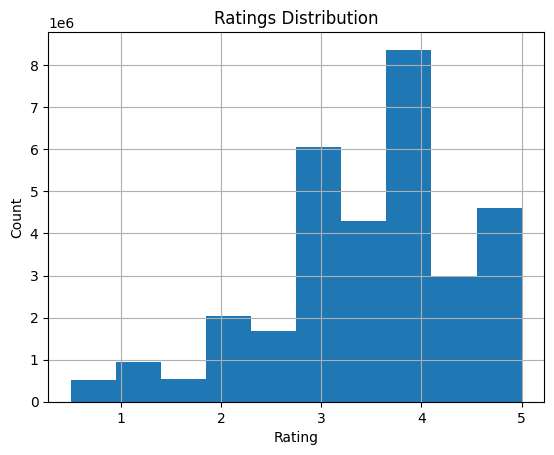


Top Genres:

{'Drama': 34175, 'Comedy': 23124, 'Thriller': 11823, 'Romance': 10369, 'Action': 9668, 'Documentary': 9363, 'Horror': 8654, '(no genres listed)': 7080, 'Crime': 6976, 'Adventure': 5402}


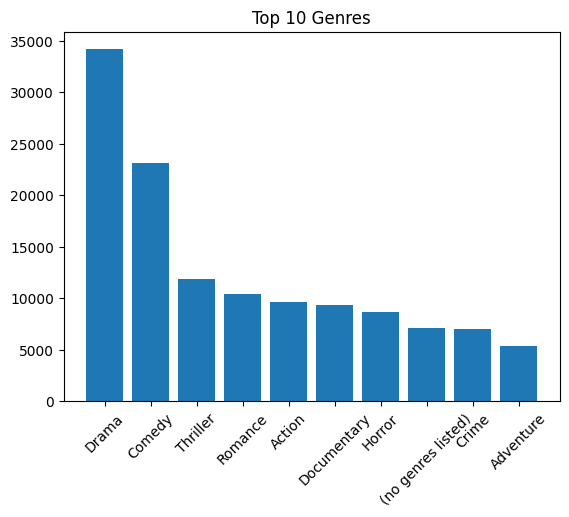

/tmp/ipykernel_17898/1823290011.py:65: PerformanceWarning: The following operation may generate 16927658572 cells in the resulting pandas object.
  user_movie_matrix = df.pivot_table(index='userId', columns='title', values='rating')


In [ ]:
# ================================
# IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ================================
# LOAD DATASET
# ================================
movies = pd.read_csv("/movies.csv")
ratings = pd.read_csv("/ratings.csv")

# ================================
# MERGE DATA
# ================================
df = pd.merge(ratings, movies, on='movieId')

# ================================
# CLEAN DATA
# ================================
df.dropna(inplace=True)

# ================================
# ===== DAY 1: EDA =========
# ================================

print("\nTop 10 Most Rated Movies:\n")
print(df['title'].value_counts().head(10))

print("\nTop 10 Highest Rated Movies:\n")
avg_rating = df.groupby('title')['rating'].mean().sort_values(ascending=False)
print(avg_rating.head(10))

# Ratings Distribution
plt.figure()
df['rating'].hist()
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# Genre Analysis
movies['genres'] = movies['genres'].apply(lambda x: x.split('|'))
all_genres = [g for sub in movies['genres'] for g in sub]
genre_count = Counter(all_genres)

print("\nTop Genres:\n")
print(dict(genre_count.most_common(10)))

# Plot Top Genres
top_genres = dict(genre_count.most_common(10))
plt.figure()
plt.bar(top_genres.keys(), top_genres.values())
plt.xticks(rotation=45)
plt.title("Top 10 Genres")
plt.show()

# ================================
# ===== DAY 2: RECOMMENDER =======
# ================================

# Create User-Movie Matrix
user_movie_matrix = df.pivot_table(index='userId', columns='title', values='rating')

# Fill missing values
user_movie_matrix.fillna(0, inplace=True)

# Recommendation Function
def recommend(movie_name):
    if movie_name not in user_movie_matrix.columns:
        return "Movie not found in dataset"

    similar_movies = user_movie_matrix.corrwith(user_movie_matrix[movie_name])
    similar_movies = similar_movies.dropna()
    similar_movies = similar_movies.sort_values(ascending=False)
    similar_movies = similar_movies.drop(movie_name, errors='ignore')

    return similar_movies.head(10)

# ================================
# TEST RECOMMENDATION
# ================================

print("\nRecommendations for Toy Story (1995):\n")
print(recommend("Toy Story (1995)"))

print("\nRecommendations for Jumanji (1995):\n")
print(recommend("Jumanji (1995)"))

Filtered Data Shape: (49065, 6)

Top Movies:

title
Toy Story (1995)                     500
Terminator 2: Judgment Day (1991)    500
Silence of the Lambs, The (1991)     500
Pulp Fiction (1994)                  500
Jurassic Park (1993)                 500
Name: count, dtype: int64


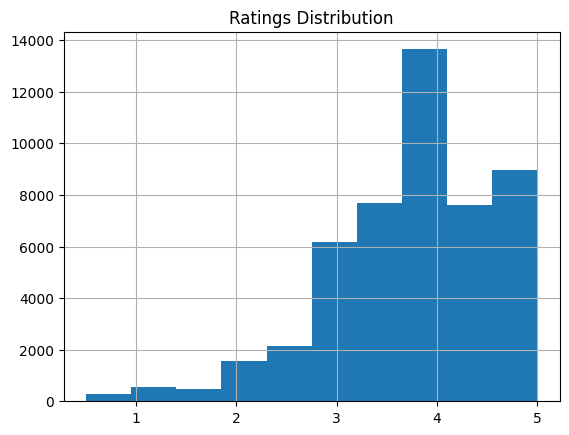

Matrix Shape: (500, 100)

Recommendations:

                                                movie     score
56                                   Mask, The (1994)  0.939044
48                               Jurassic Park (1993)  0.932795
25             Dumb & Dumber (Dumb and Dumber) (1994)  0.932760
87  Star Wars: Episode VI - Return of the Jedi (1983)  0.932112
89                  Terminator 2: Judgment Day (1991)  0.931326
59                   Men in Black (a.k.a. MIB) (1997)  0.930067
70                                Pulp Fiction (1994)  0.929519
90                             Terminator, The (1984)  0.929474
85          Star Wars: Episode IV - A New Hope (1977)  0.928921
34         Ghostbusters (a.k.a. Ghost Busters) (1984)  0.928417


In [ ]:
# ================================
# IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================
# LOAD DATASET
# ================================
movies = pd.read_csv("/movies.csv")
ratings = pd.read_csv("/ratings.csv")

# ================================
# MERGE DATA
# ================================
df = pd.merge(ratings, movies, on='movieId')
df.dropna(inplace=True)

# ================================
# 🔥 STRONG FILTERING (VERY IMPORTANT)
# ================================

# Keep only top 100 movies (VERY SAFE)
top_movies = df['title'].value_counts().head(100).index
df = df[df['title'].isin(top_movies)]

# Keep only active users
active_users = df['userId'].value_counts().head(500).index
df = df[df['userId'].isin(active_users)]

print("Filtered Data Shape:", df.shape)

# ================================
# SIMPLE EDA
# ================================
print("\nTop Movies:\n")
print(df['title'].value_counts().head())

plt.figure()
df['rating'].hist()
plt.title("Ratings Distribution")
plt.show()

# ================================
# CREATE MATRIX (NOW SAFE)
# ================================
user_movie_matrix = df.pivot_table(index='userId', columns='title', values='rating').fillna(0)

print("Matrix Shape:", user_movie_matrix.shape)

# ================================
# LIGHTWEIGHT RECOMMENDER
# ================================

def recommend(movie_name):
    if movie_name not in user_movie_matrix.columns:
        return "Movie not found"

    # Use cosine similarity manually (lighter)
    from sklearn.metrics.pairwise import cosine_similarity

    movie_vector = user_movie_matrix[movie_name].values.reshape(1, -1)

    similarity = cosine_similarity(movie_vector, user_movie_matrix.T)[0]

    sim_df = pd.DataFrame({
        'movie': user_movie_matrix.columns,
        'score': similarity
    })

    sim_df = sim_df.sort_values(by='score', ascending=False)

    return sim_df[sim_df['movie'] != movie_name].head(10)

# ================================
# TEST
# ================================
print("\nRecommendations:\n")
print(recommend(user_movie_matrix.columns[0]))

In [ ]:
import pandas as pd
from pathlib import Path

# --- paths (works whether you run from repo root or Notebooks folder) ---
cwd = Path.cwd()
if (cwd / "Data" / "MovieLens" / "ratings.csv").exists():
    root = cwd
else:
    root = cwd.parent

movies_path = root / "Data" / "MovieLens" / "movies.csv"
ratings_path = root / "Data" / "MovieLens" / "ratings.csv"
out_dir = root / "Data" / "MovieLens"

TOP_N_MOVIES = 100   # same as notebook idea
TOP_N_USERS  = 500   # same as notebook idea

# --- load only needed columns to save memory ---
movies = pd.read_csv(movies_path, usecols=["movieId", "title", "genres"])
ratings = pd.read_csv(ratings_path, usecols=["userId", "movieId", "rating", "timestamp"])

# --- filter: top movies by number of ratings ---
top_movie_ids = ratings["movieId"].value_counts().head(TOP_N_MOVIES).index
ratings_f = ratings[ratings["movieId"].isin(top_movie_ids)].copy()

# --- filter: top active users by number of ratings ---
top_user_ids = ratings_f["userId"].value_counts().head(TOP_N_USERS).index
ratings_f = ratings_f[ratings_f["userId"].isin(top_user_ids)].copy()

# --- merge with movie info (for interpretability) ---
filtered_df = ratings_f.merge(movies, on="movieId", how="left").dropna()

# --- save outputs ---
filtered_csv = out_dir / "movies_data.csv"          # merged: userId,movieId,rating,timestamp,title,genres
filtered_ratings_csv = out_dir / "filtered_ratings.csv"  # ratings only

filtered_df.to_csv(filtered_csv, index=False)
ratings_f.to_csv(filtered_ratings_csv, index=False)

print("Saved:")
print(" -", filtered_csv)
print(" -", filtered_ratings_csv)
print("Filtered shape:", filtered_df.shape)